In [1]:
%load_ext autoreload
%autoreload 2

import pygtfcode as gtf
from pprint import pprint

# Frank core-in-core example

In [2]:
config = gtf.Config()
config.init = ('truncated_NFW', {'Zt': 0.00807, 'deltaP': 1.0e-5, 'Mvir': 1.0e12, 'cvir': 30})

config.sim.sigma_m = 250
config.sim.c = 0.88
config.sim.t_halt = 1.0e6
config.sim.rho_c_halt = 1.0e6

config.prec.eps_dt = 1.0e-3
config.prec.eps_du = 1.0e-6

config.grid.rmin = 0.01
config.grid.rmax = 500
config.grid.ngrid = 500


config.io.model_no = 100

In [3]:
state = gtf.State.from_config(config)

Computing characteristic parameters for simulation...
Generating lookup for rho(phi)...
Computing potential profile for truncated NFW halo...
Integrating Poisson equation outward: r = 1172.651400, phi = -0.000000
Setting up radial grid...
Initializing profiles...
Computing Menc: r = 345.848, m = 4.619

/Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/pygtfcode/profiles/truncated_nfw.py:274: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(


Computing Menc: r = 500.000, m = 4.806
Generating lookup for v2 integrand...
Computing v2: r = 494.638, v2 = 0.002
Ensuring initial hydrostatic equilibrium...
Hydrostatic equilibrium achieved in 4 iterations. Max |dr/r|/eps_dr = 1.17e-03
State initialized.
Directory already exists: /Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments/Model100
Model information written to model_metadata.txt
Initial profiles written to disk.


In [4]:
state.run()

Initial profiles written to disk.
Time evolution file initialized.
Log file initialized:
      step          time          <dt>         rho_c         v_max        Kn_min  <dt lim>  <dr lim>  <du lim>  <n_iter_cr>  <n_iter_dr>
         0  0.000000e+00           N/A  1.565494e+02  3.070067e-01  3.279760e-02       N/A       N/A       N/A          N/A          N/A
    100000  3.645376e+00  3.645376e-05  1.448547e+02  3.070490e-01  3.336831e-02  5.45e-01  1.47e-02  9.50e-01  0.00000e+00  1.00000e+00
    200000  7.330719e+00  3.685343e-05  1.340741e+02  3.070903e-01  3.393870e-02  5.21e-01  1.32e-02  9.50e-01  0.00000e+00  1.00000e+00
    300000  1.104742e+01  3.716698e-05  1.241495e+02  3.071318e-01  3.450637e-02  4.97e-01  1.27e-02  9.50e-01  0.00000e+00  1.00000e+00
    400000  1.479700e+01  3.749582e-05  1.150096e+02  3.071734e-01  3.507083e-02  4.75e-01  1.24e-02  9.50e-01  0.00000e+00  1.00000e+00
    500000  1.858314e+01  3.786139e-05  1.065875e+02  3.072153e-01  3.563200e-02  4.54e-0

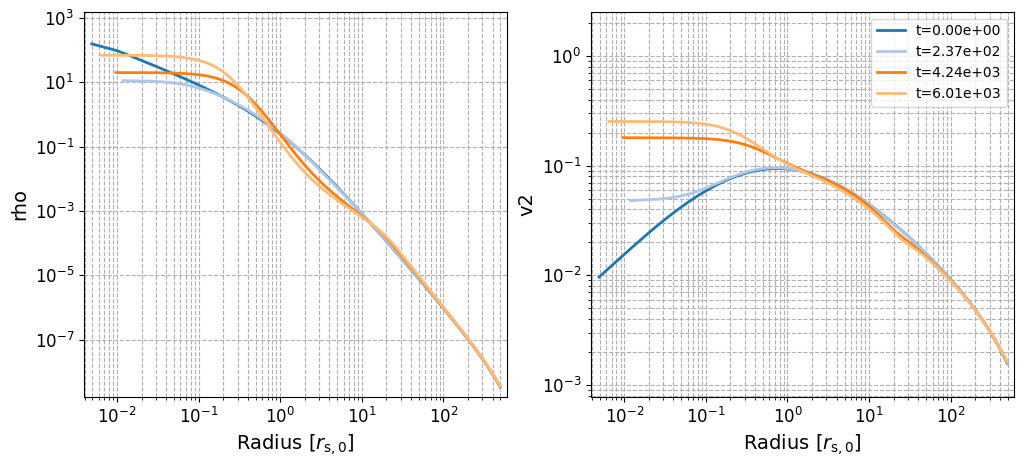

In [5]:
# from pygtfcode import plot_snapshots
gtf.plot_snapshots(state, [0,25,50,63], profiles=['rho','v2'], grid=True)

In [7]:
state.make_movie(profiles=['rho', 'v2', 'kn'])

Generating 165 frames...


Frames: 100%|██████████| 165/165 [01:20<00:00,  2.04frame/s]


Compiling into a movie using ffmpeg...
Deleting frames...
Movie saved to /Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments/Model100/movie_rho_v2_kn.mp4
